# SOCIAL NETWORK ANALYSIS: CORSO INTRODUTTIVO

### TC CSArs Calanna

<b>AVVERTENZA</b>: la presente esercitazionè si pone l'obiettivo di introdurre i frequentatori ai rudimenti della <em>Social Network Analysis</em> e alle sue possibili applicazioni nel campo della selezione del personale AM (con particolare riferimento alle prove di gruppo) o negli interventi di miglioramento organizzativo. In nessun modo, tale esercitazione può considerarsi esaustiva della materia. Per approfondire alcuni degli argomenti esposti, consiglio di leggere la seguente pubblicazione (anche se datata): Wasserman, S., & Faust, K. (1994). Social network analysis: Methods and applications.

In [1]:
# librerie
import string
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import FunctionTransformer
pd.set_option('display.max_columns', None)

In [2]:
# costanti
FIG_SIZE = (8,8)
SEED = 42
K_VALUE = .4
NODE_OPTIONS = {
    "node_size": 450,
    "node_color": "white",
    "edgecolors": "black",
}
BASE_OPTIONS = {
    "font_color": "black",
    "linewidths": 1,
    "width": 1,
    "arrowsize": 25
} | NODE_OPTIONS
FIXED = {
    "A": [ 0.56183978, -0.20152870],
    "B": [ 0.28101873, -0.52749403],
    "C": [-0.41912650 , 0.08834984],
    "D": [ 0.10867974, -0.23408142],
    "E": [-0.07909418, -0.62303526],
    "F": [ 0.23605847,  0.16287024],
    "G": [-0.07094198, -0.12071275],
    "H": [-0.20416911,  0.45563209],  
    "I": [-0.41426495,  1.00000000],
}

In [3]:
# carica network
U = nx.read_edgelist("U.edgelist")
D = nx.read_edgelist("D.edgelist", create_using=nx.DiGraph)
spring = nx.spring_layout(U, seed=SEED, pos=FIXED)

In [4]:
# funzioni 
def plot_network(G, plot = None):
    fig, ax = plt.subplots(figsize=FIG_SIZE) if plot == None else plot
    ax.axis('off')
    if G.is_directed():
        mutual_edges, non_mutual_edges = get_mutual_non_mutual_edges(G.edges)
        nx.draw_networkx_nodes(G, spring, **NODE_OPTIONS, ax=ax);
        nx.draw_networkx_edges(G, spring, edgelist = non_mutual_edges, style="--", arrowsize=25, ax=ax);
        nx.draw_networkx_edges(G, spring, edgelist = mutual_edges, width=4, arrowstyle="-", ax=ax);
        nx.draw_networkx_labels(G, spring, ax=ax)
    else:
        nx.draw_networkx(G, spring,**BASE_OPTIONS, ax=ax)
    return fig, ax

def biplot(R, node_size, cmap, title):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14,6))
    for ax in [ax1, ax2]: ax.axis('off')
    plot_network(R, (fig, ax1));
    if R.is_directed():
        mutual_edges, non_mutual_edges = get_mutual_non_mutual_edges(R.edges)
        nx.draw_networkx_nodes(R, spring, ax=ax2, node_size=node_size,
                cmap=cmap, node_color=node_size, vmin=-500, vmax=max(node_size))
        nx.draw_networkx_edges(R, spring, edgelist = non_mutual_edges, style="--", arrowsize=25, ax=ax);
        nx.draw_networkx_edges(R, spring, edgelist = mutual_edges, width=4, arrowstyle="-", ax=ax);
        nx.draw_networkx_labels(R, spring, font_color="white", ax=ax)
    else:
        opts = { "font_color": "white", "edgecolors": "black", "linewidths": 1, "width": 1 }
        nx.draw_networkx(R, spring, ax=ax2, node_size=node_size, **opts, 
                cmap=cmap, node_color=node_size, vmin=-500, vmax=max(node_size))
    ax.set_title(title);

def get_mutual_non_mutual_edges(edges):
    mutual_edges = [e for e in edges if e[::-1] in edges]
    non_mutual_edges = [e for e in edges if e not in mutual_edges]
    return (mutual_edges, non_mutual_edges)

def cmap_fn(values):
    reshaped = values.to_numpy().reshape(-1,1)
    return MinMaxScaler().fit_transform(reshaped) * 700 + 200

cmap_transformer = FunctionTransformer(cmap_fn)

## 1.1 DEFINIZIONE DI SOCIAL NETWORK ANALYSIS

L'analisi delle reti sociali (<em>Social Network Analysis</em> - SNA) è un corpus eterogeno di approcci teorici, tecniche e algoritmi computazionali per indagare le strutture sociali. La SNA caratterizza tali strutture in termini di nodi (attori, persone) e di collegamenti tra nodi (relazioni, interazioni). Quanto segue è un'introduzione minima ai concetti della SNA descrittiva e, in particolare, alle misure quantitative che saranno usate per analizzare le interviste di gruppo. 

## 1.2 ELEMENTI DI BASE

Una rete è un sistema di elementi (NODI) e delle relazioni intercorrenti tra essi (COLLEGAMENTI). 

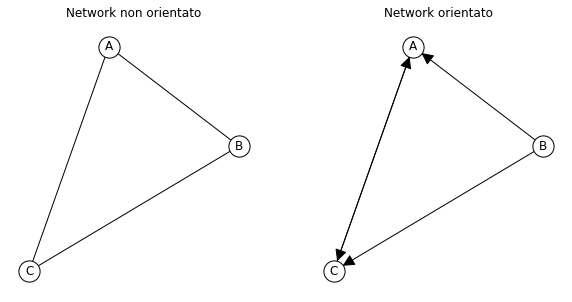

In [5]:
# Network non orientato
fig, (ax1, ax2) = plt.subplots(figsize=(10,5), nrows=1, ncols=2)
for ax in (ax1, ax2): ax.axis('off')
    
Tu = nx.Graph(nx.utils.pairwise(["A","B","C"], cyclic=True))
nx.draw_networkx(Tu, nx.random_layout(Tu, seed=SEED), **BASE_OPTIONS, ax=ax1)
Td = nx.triad_graph("120D")
Td = nx.relabel_nodes(Td, dict(zip(Td, string.ascii_uppercase)))
nx.draw_networkx(Td, nx.random_layout(Td, seed=SEED), **BASE_OPTIONS, ax=ax2);
ax1.set_title("Network non orientato")
ax2.set_title("Network orientato");

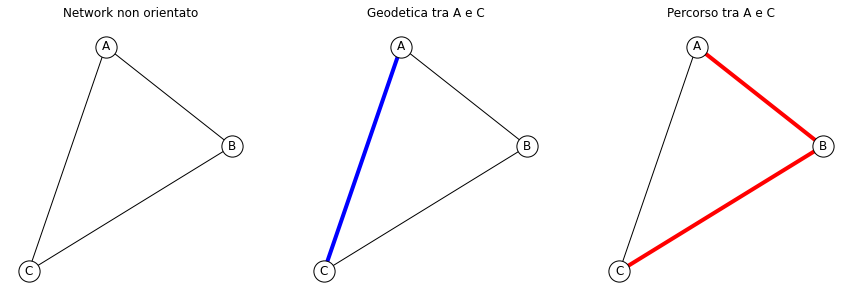

In [6]:
# Esempi di percorso
# (il percorso più breve tra due nodi si chiama geodetica)
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(15,5), nrows=1, ncols=3)
for ax in (ax1, ax2, ax3): 
    ax.axis('off')
    nx.draw_networkx(Tu, nx.random_layout(Td, seed=SEED), **BASE_OPTIONS, ax=ax)
nx.draw_networkx_edges(Tu, nx.random_layout(Td, seed=SEED), edgelist=[("A","C")], 
    edge_color="b", width=4, ax=ax2)
nx.draw_networkx_edges(Tu, nx.random_layout(Td, seed=SEED), 
    edgelist=list(nx.utils.pairwise(["A","B","C"])), edge_color="r", width=4, ax=ax3);
ax1.set_title("Network non orientato")
ax2.set_title("Geodetica tra A e C");
ax3.set_title("Percorso tra A e C");

## 1.3 LIVELLI DI ANALISI

- Livello <b>MACRO</b>: analisi delle caratterische globali della rete (es., visualizzazione, diametro, centralizzazione, transitività, densità)
- Livello <b>MICRO</b>: analisi dell caratteristiche dei singoli nodi all'interno della rete (es., centralità dei nodi)
- Livello <b>MESO</b>: analisi delle strutture intermedie della rete (es., triadi, clique, k-core)

## 1.4 Livello MACRO

### 1.4.1 Visualizzazione (Force-Directed Layout)

Force-directed graph drawing algorithms are a class of algorithms for drawing graphs in an aesthetically-pleasing way. Their purpose is to position the nodes of a graph in two-dimensional or three-dimensional space so that all the edges are of more or less equal length and there are as few crossing edges as possible, by assigning forces among the set of edges and the set of nodes, based on their relative positions, and then using these forces either to simulate the motion of the edges and nodes or to minimize their energy.
The Fruchterman-Reingold algorithm simulates a force-directed representation of the network treating edges as springs holding nodes close, while treating nodes as repelling objects, sometimes called an anti-gravity force. Simulation continues until the positions are close to an equilibrium.

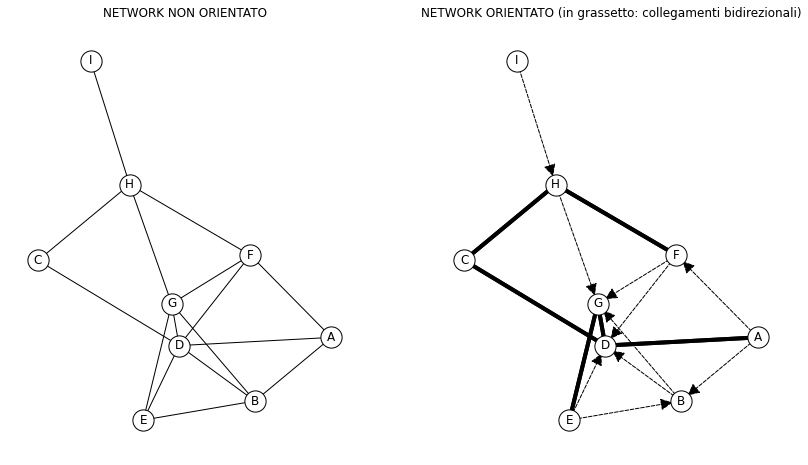

In [7]:
# network non orientato e orientato
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14,8))
plot_network(U, (fig, ax1))
fig, ax = plot_network(D, (fig, ax2))
ax1.set_title("NETWORK NON ORIENTATO");
ax2.set_title("NETWORK ORIENTATO (in grassetto: collegamenti bidirezionali)");

### 1.4.2 Diameter
The diameter of a connected graph is the maximum length of a shortest path. In other words, it is the maximum of the distances between pairs of vertices in the graph. For disconnected graphs, definitions vary: the diameter may be defined as infinite, or as the largest diameter of a connected component, or it may be undefined.

In [8]:
f"diametro del network: {nx.diameter(U)}"

'diametro del network: 3'

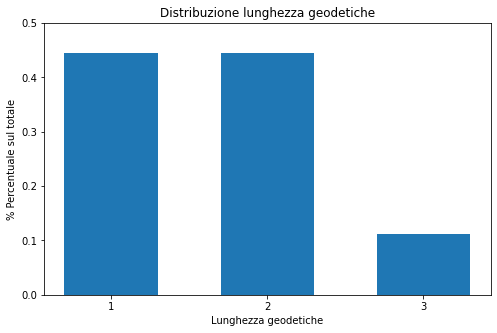

In [9]:
# Distribuzione lunghezza geodetiche
fig, ax = plt.subplots(figsize=(8,5))
dict_shortest = dict(nx.shortest_path_length(U))
flattened_shortest = sum(map(lambda x: list(x.values()), dict_shortest.values()), [])
flattened_shortest = [x for x in flattened_shortest if x > 0]
max_geodetic = max(flattened_shortest)
bins = [0.5 + i for i in range(max_geodetic + 1)]
g = ax.hist(flattened_shortest, bins=bins, rwidth=.6, density=True)
ax.set_title("Distribuzione lunghezza geodetiche")
ax.set_xlabel("Lunghezza geodetiche")
ax.set_ylabel("% Percentuale sul totale")
ax.set_xticks(list(map(int, bins[1:])))
ax.set_ylim(0,.5);

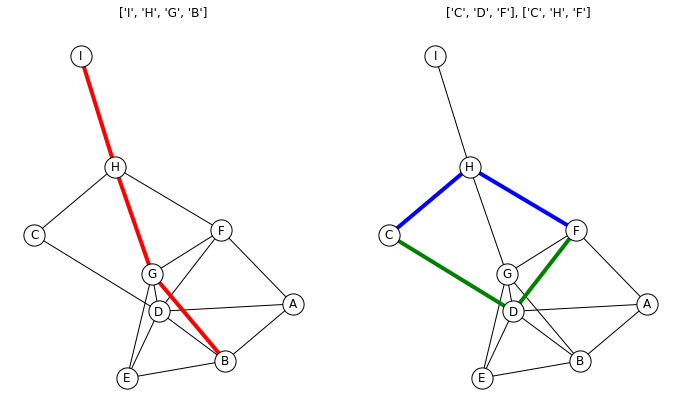

In [10]:
# esempi di geodetiche
fig, (ax1, ax2) = plt.subplots(figsize=(10,6), nrows=1, ncols=2)
fig.tight_layout()
for ax in (ax1, ax2): 
    ax.axis('off')
    nx.draw_networkx(U, spring, **NODE_OPTIONS, ax=ax)
IB_shortest_paths = list(nx.all_shortest_paths(U, "I", "B"))
CF_shortest_paths = list(nx.all_shortest_paths(U, "C", "F"))
geo1_edges = list(nx.utils.pairwise(IB_shortest_paths[0]))
geo2_edges = list(nx.utils.pairwise(CF_shortest_paths[0]))
geo3_edges = list(nx.utils.pairwise(CF_shortest_paths[1]))
for (edge_list, color, ax) in [(geo1_edges, "r", ax1),(geo2_edges, "g", ax2),(geo3_edges, "b", ax2)]:
    nx.draw_networkx_edges(U, spring, edgelist=edge_list, edge_color=color, width=4, ax=ax)
ax1.set_title(IB_shortest_paths[0])
ax2.set_title(f"{CF_shortest_paths[0]}, {CF_shortest_paths[1]}");

### 1.4.3 Centralization and Transitivity

- <b>Centralization</b>: centralization expresses how much a network is organized around a focal point (or some focal points).
- <b>Transitivity</b>: transitivity indcates the propensity of a network to form closed triads and - more generaly - clusters of nodes highly connected.

In [11]:
def get_centralization(G):
    n = G.order()
    centrality_values = dict(G.degree()).values()
    c_max = max(centrality_values)
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))

f"centralizzazione: {np.round(get_centralization(U),2)}, transitivity: {np.round(nx.transitivity(U),2)}"

'centralizzazione: 0.39, transitivity: 0.48'

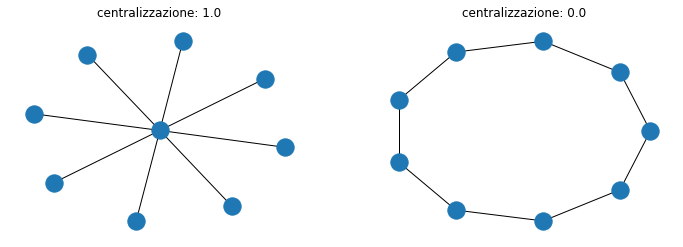

In [12]:
# esempi di centralizzazione
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
S = nx.Graph()
S.add_nodes_from(range(U.order()))
nx.add_star(S, S.nodes())
loc = nx.spring_layout(S)
nx.draw(S, loc, ax=ax1)
ax1.set_title(f"centralizzazione: {get_centralization(S)}")
C = nx.watts_strogatz_graph(U.order(), 2, 0)
loc = nx.circular_layout(C)
nx.draw(C,loc, ax=ax2)
ax2.set_title(f"centralizzazione: {get_centralization(C)}");

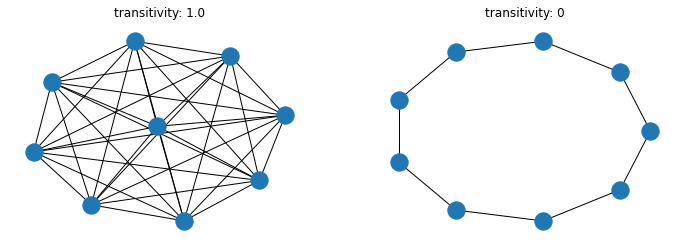

In [13]:
# esempi di transitity
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
S = nx.complete_graph(U.order())
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"transitivity: {np.round(nx.transitivity(S),3)}")
C = nx.watts_strogatz_graph(U.order(), 2, 0, seed=42)
loc = nx.circular_layout(C)
nx.draw(C,loc,ax=ax2)
ax2.set_title(f"transitivity: {np.round(nx.transitivity(C),3)}");

### 1.4.4. Density

Network density describes the portion of the potential connections in a network that are actual connections

In [14]:
f"densità: {np.round(nx.density(U),2)}"

'densità: 0.44'

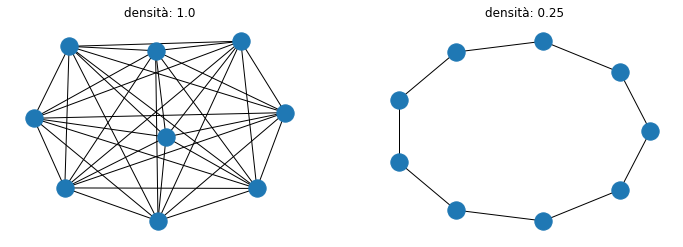

In [15]:
# esempi di transitity
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
S = nx.complete_graph(U.order())
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"densità: {np.round(nx.density(S),3)}")
C = nx.watts_strogatz_graph(U.order(), 2, 0, seed=42)
loc = nx.circular_layout(C)
nx.draw(C,loc,ax=ax2)
ax2.set_title(f"densità: {np.round(nx.density(C),3)}");

## 1.5 Livello MICRO

### 1.5.1 Degree centrality and Eigenvector centrality (per network non orientati)

- <b>Degree centrality</b>: the number of links incident upon a node (i.e., the number of ties that a node has).
- <b>Eigenvector centrality</b>: a natural extension of Degree centrality. In-degree centrality awards one centrality point for every link a node receives. But not all vertices are equivalent: some are more relevant than others, and, reasonably, endorsements from important nodes count more. The eigenvector centrality thesis reads: A node is important if it is linked to by other important nodes. Eigenvector centrality differs from in-degree centrality: a node receiving many links does not necessarily have a high eigenvector centrality (it might be that all linkers have low or null eigenvector centrality). Moreover, a node with high eigenvector centrality is not necessarily highly linked (the node might have few but important linkers).

In [16]:
deg = dict(U.degree())
deg_df = pd.DataFrame({ 
    "degree": pd.Series(deg),
    "degree_rnk": pd.Series(deg).rank(method="dense", ascending=False).astype("int"), 
})
degrees = cmap_transformer.fit_transform(deg_df["degree"])
deg_df.sort_values(by="degree", ascending=False)

,degree,degree_rnk
D,6,1
G,5,2
B,4,3
F,4,3
H,4,3
E,3,4
A,3,4
C,2,5
I,1,6


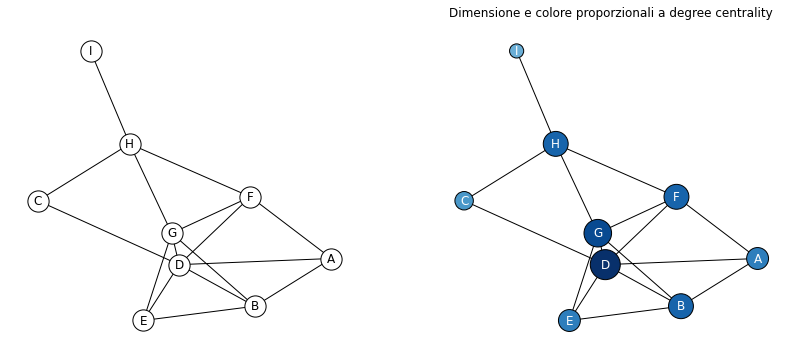

In [17]:
biplot(U, degrees, plt.cm.Blues, "Dimensione e colore proporzionali a degree centrality")

In [18]:
eig = { k: round(v,2) for k,v in dict(nx.eigenvector_centrality(U)).items()}
eig_df = pd.DataFrame({ 
    "eigenvector": pd.Series(eig),
    "eigenvector_rnk": pd.Series(eig).rank(method="dense", ascending=False).astype("int")
})
eigens = cmap_transformer.fit_transform(eig_df["eigenvector"])
eig_df.sort_values(by="eigenvector", ascending=False)

,eigenvector,eigenvector_rnk
D,0.49,1
G,0.44,2
B,0.38,3
F,0.36,4
E,0.32,5
A,0.30,6
H,0.26,7
C,0.18,8
I,0.06,9


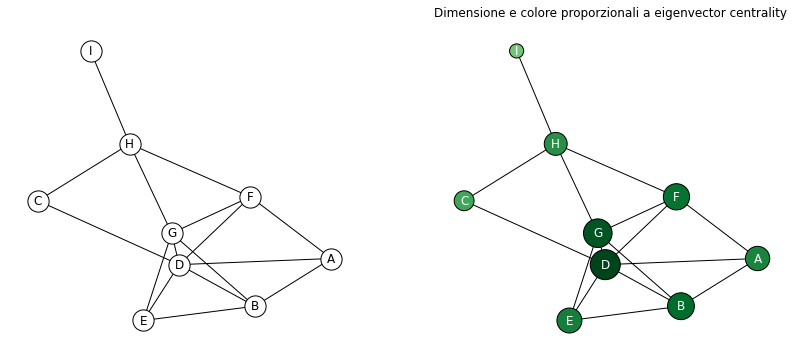

In [19]:
biplot(U, eigens, plt.cm.Greens, "Dimensione e colore proporzionali a eigenvector centrality")

### 1.5.2 InDegree centrality e PageRank centrality (per network orientati)

- <b>InDegree centrality</b>: In-degree is the number of connections that point inward at a node (Out-degree is the number of connections that originate at a node and point outward to other nodes).
- <b>PageRank centrality</b>: there are three distinct factors that determine the PageRank of a node: (i) the number of links it receives, (ii) the link propensity of the linkers, and (iii) the centrality of the linkers. The first factor is not surprising: the more links a node attracts, the more important it is perceived. Reasonably, the value of the endorsement depreciates proportionally to the number of links given out by the endorsing node: links coming from parsimonious nodes are worthier than those emanated by spendthrift ones. Finally, not all nodes are created equal: links from important vertices are more valuable than those from obscure ones. This method has been coined (and patented) by Sergey Brin and Larry Page (The anatomy of a large-scale hypertextual web search engine. Computer networks and ISDN systems, 1998)

In [20]:
ind = dict(D.in_degree())
ind_df = pd.DataFrame({ 
    "in_degree": pd.Series(ind),
    "in_degree_rnk": pd.Series(ind).rank(method="dense", ascending=False).astype("int")
})
indegrees = cmap_transformer.fit_transform(ind_df["in_degree"])
ind_df.sort_values(by="in_degree", ascending=False)

,in_degree,in_degree_rnk
D,6,1
G,5,2
H,3,3
B,2,4
C,2,4
F,2,4
E,1,5
A,1,5
I,0,6


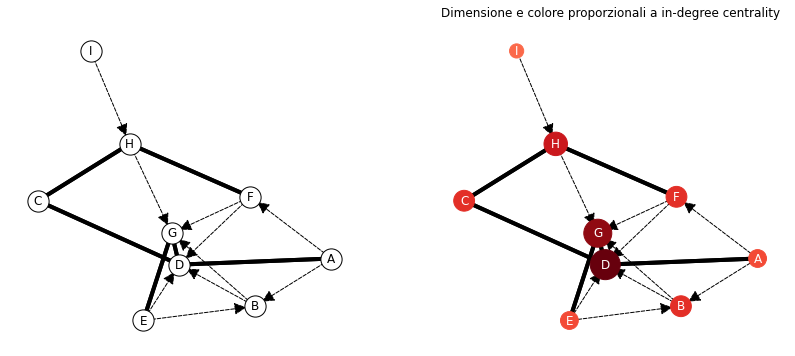

In [21]:
biplot(D, indegrees, plt.cm.Reds, "Dimensione e colore proporzionali a in-degree centrality");

In [22]:
prk = { k: round(v,2) for k,v in dict(nx.pagerank(D)).items()}
prk_df = pd.DataFrame({ 
    "pagerank": pd.Series(prk),
    "pagerank_rnk": pd.Series(prk).rank(method="dense", ascending=False).astype("int")
})
prks = cmap_transformer.fit_transform(prk_df["pagerank"])
prk_df.sort_values(by="pagerank", ascending=False)

,pagerank,pagerank_rnk
D,0.25,1
G,0.19,2
C,0.12,3
E,0.10,4
H,0.10,4
A,0.09,5
B,0.07,6
F,0.07,6
I,0.02,7


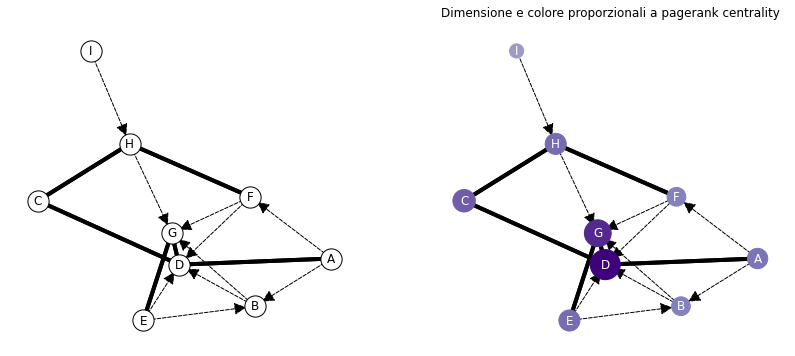

In [23]:
biplot(D, prks, plt.cm.Purples, "Dimensione e colore proporzionali a pagerank centrality");

### 1.5.3 Closenness centrality (per network orientati e non)

Closeness centrality indicates how close a node is to all other nodes in the network. It is calculated as the average of the shortest path length from the node to every other node in the network.

In [24]:
clos = dict(nx.closeness_centrality(U))
uclo_df = pd.DataFrame({ 
    "closeness": pd.Series(clos).round(2),
    "closeness_rnk": pd.Series(clos).round(2).rank(method="dense", ascending=False).astype("int")
})
closeness = cmap_transformer.fit_transform(uclo_df["closeness"])
uclo_df.sort_values(by="closeness", ascending=False)

,closeness,closeness_rnk
G,0.73,1
D,0.73,1
F,0.67,2
H,0.67,2
B,0.62,3
E,0.57,4
A,0.57,4
C,0.57,4
I,0.42,5


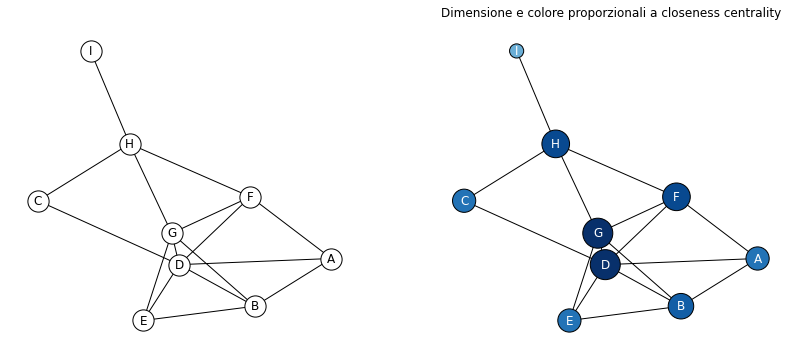

In [25]:
biplot(U, closeness, plt.cm.Blues, "Dimensione e colore proporzionali a closeness centrality")

### 1.5.4 Betwenness Centrality

Betweenness centrality is a way of detecting the amount of influence a node has over the flow of information in a graph. It is often used to find nodes that serve as a bridge from one part of a graph to another.The algorithm calculates unweighted shortest paths between all pairs of nodes in a graph. Each node receives a score, based on the number of shortest paths that pass through the node. Nodes that more frequently lie on shortest paths between other nodes will have higher betweenness centrality scores.

In [26]:
bet = dict(nx.betweenness_centrality(U))
ubet_df = pd.DataFrame({ 
    "betweenness": pd.Series(bet).round(2),
    "betweenness_rnk": pd.Series(bet).round(2).rank(method="dense", ascending=False).astype("int")
})
betweenness = cmap_transformer.fit_transform(ubet_df["betweenness"])
ubet_df.sort_values(by="betweenness", ascending=False)

,betweenness,betweenness_rnk
H,0.29,1
G,0.20,2
D,0.20,2
F,0.11,3
B,0.03,4
C,0.02,5
A,0.01,6
E,0.00,7
I,0.00,7


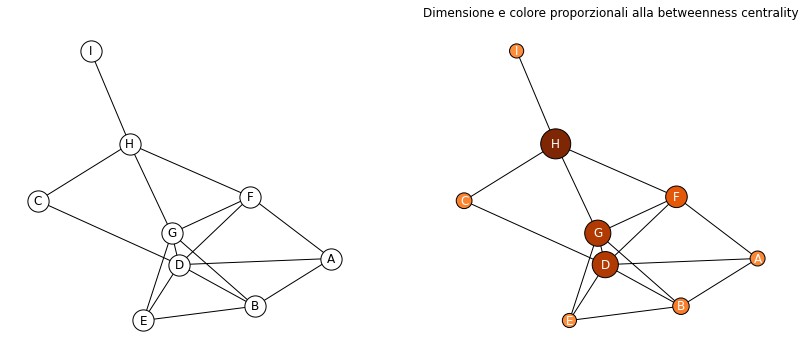

In [27]:
biplot(U, betweenness, plt.cm.Oranges, "Dimensione e colore proporzionali alla betweenness centrality")

## 1.6 Livello MESO

### 1.6.1 Triangoli

A triangle consists of a closed triplet of nodes.

[['G', 'B', 'D'],
 ['G', 'B', 'E'],
 ['G', 'D', 'F'],
 ['G', 'D', 'E'],
 ['G', 'F', 'H'],
 ['B', 'D', 'E'],
 ['B', 'D', 'A'],
 ['D', 'F', 'A']]

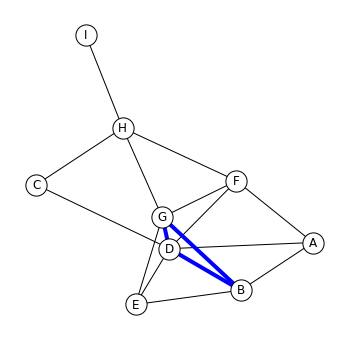

In [28]:
# elenca triangli, visualizza un triangolo 
all_cliques = list(nx.enumerate_all_cliques(U))
triangles = [clq for clq in all_cliques if len(clq) == 3]
display(triangles)
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')
nx.draw_networkx(U, spring, **BASE_OPTIONS, ax=ax)
edges = U.copy().subgraph(triangles[0]).edges()
nx.draw_networkx_edges(U, spring, edgelist=edges, edge_color="b", width=4, ax=ax);

In [29]:
# censimento triadico
# M-A-N  Mutual edge - Asymmetrical edge - No edge
display(f"numero di triangoli totale: {len(list(nx.all_triplets(U.to_directed())))}")
display({ k: list(map(list,v)) for k,v in nx.triads_by_type(U.to_directed()).items() })

'numero di triangoli totale: 84'

{'300': [['D', 'G', 'B'],
  ['E', 'G', 'B'],
  ['F', 'G', 'D'],
  ['E', 'G', 'D'],
  ['F', 'G', 'H'],
  ['D', 'E', 'B'],
  ['D', 'A', 'B'],
  ['F', 'A', 'D']],
 '201': [['F', 'G', 'B'],
  ['H', 'G', 'B'],
  ['A', 'G', 'B'],
  ['H', 'G', 'D'],
  ['A', 'G', 'D'],
  ['C', 'G', 'D'],
  ['F', 'E', 'G'],
  ['F', 'A', 'G'],
  ['H', 'E', 'G'],
  ['C', 'H', 'G'],
  ['H', 'G', 'I'],
  ['D', 'F', 'B'],
  ['D', 'C', 'B'],
  ['F', 'A', 'B'],
  ['A', 'E', 'B'],
  ['F', 'E', 'D'],
  ['H', 'F', 'D'],
  ['C', 'F', 'D'],
  ['A', 'E', 'D'],
  ['C', 'E', 'D'],
  ['C', 'H', 'D'],
  ['C', 'A', 'D'],
  ['F', 'A', 'H'],
  ['C', 'F', 'H'],
  ['F', 'I', 'H'],
  ['C', 'H', 'I']],
 '102': [['C', 'G', 'B'],
  ['G', 'I', 'B'],
  ['G', 'I', 'D'],
  ['C', 'F', 'G'],
  ['F', 'G', 'I'],
  ['A', 'E', 'G'],
  ['C', 'E', 'G'],
  ['E', 'G', 'I'],
  ['H', 'A', 'G'],
  ['D', 'H', 'B'],
  ['D', 'I', 'B'],
  ['F', 'E', 'B'],
  ['H', 'F', 'B'],
  ['H', 'E', 'B'],
  ['C', 'E', 'B'],
  ['E', 'I', 'B'],
  ['H', 'A', 'B'],
  ['C', 

### 1.6.2 CLIQUE

A clique is a subset of vertices of an undirected graph such that every two distinct vertices in the clique are adjacent. That is, a clique of a graph G is an induced subgraph of G that is complete.

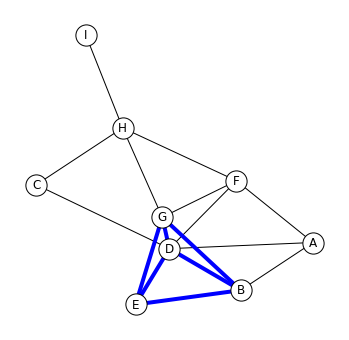

In [30]:
# visualizza clique massima
max_clique = list(nx.enumerate_all_cliques(U))[-1]
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')
nx.draw_networkx(U, spring, **BASE_OPTIONS, ax=ax)
edges = U.copy().subgraph(max_clique).edges()
nx.draw_networkx_edges(U, spring, edgelist=edges, edge_color="b", width=4, ax=ax);

### 1.6.3 K-CORE

A k-core of a network is a subgraph in which each node has at least k connections to other nodes in the subgraph.

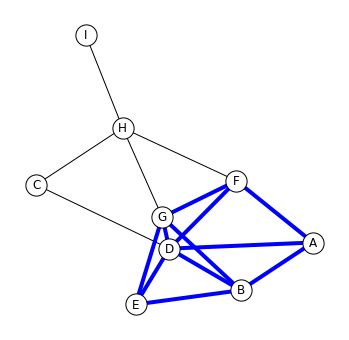

In [31]:
# K-Core con K=3
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')
nx.draw_networkx(U, spring, **BASE_OPTIONS, ax=ax)
edges = nx.algorithms.core.k_core(U, 3).edges()
nx.draw_networkx_edges(U, spring, edgelist=edges, edge_color="b", width=4, ax=ax);